# FraudSight: A Financial Fraud Detection Application
BA870 A1 / AC820 Financial Analytics

**Student Name:** Kara Liao, Inchara Ashok, Yujiun Zou

**Project Description and Motivation:**

This project develops an interactive financial fraud detection application, **FraudSight**, designed to help users identify companies with potential earnings manipulation. Financial fraud detection is challenging because financial statements contain complex information, and warning signs are often not obvious. As a result, investors and analysts must rely on time-consuming manual analysis, which may overlook important signals.

 To address this problem, we combine financial ratio analysis, the Beneish M-Score, and machine learning techniques to automatically detect abnormal reporting patterns. After comparing models, we selected Random Forest as the final model due to its superior performance in identifying fraud. The model is integrated into the app to generate fraud risk scores and provide clear, data-driven insights, enabling users to make faster and more informed decisions.

## Data Import

In [7]:
import pandas as pd
import yfinance as yf
import numpy as np

In [8]:
#yfinance data
ticker = yf.Ticker("AAPL")

income = ticker.financials.T
balance = ticker.balance_sheet.T

print("\nIncome Statement:")
print(income.head())

print("\nBalance Sheet:")
print(balance.head())


Income Statement:
            Tax Effect Of Unusual Items  Tax Rate For Calcs  \
2025-09-30                          0.0               0.156   
2024-09-30                          0.0               0.241   
2023-09-30                          0.0               0.147   
2022-09-30                          0.0               0.162   
2021-09-30                          NaN                 NaN   

            Normalized EBITDA  \
2025-09-30       1.447480e+11   
2024-09-30       1.346610e+11   
2023-09-30       1.258200e+11   
2022-09-30       1.305410e+11   
2021-09-30                NaN   

            Net Income From Continuing Operation Net Minority Interest  \
2025-09-30                                       1.120100e+11            
2024-09-30                                       9.373600e+10            
2023-09-30                                       9.699500e+10            
2022-09-30                                       9.980300e+10            
2021-09-30                       

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd


file_path = '/content/drive/MyDrive/2026 Spring/financial analytics/Financial analytics project data.csv'
data = pd.read_csv(file_path)

# check the first few rows
data.head()

,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,sic,fyear,...,lct,lt,ppent,rect,cogs,ni,revt,xsga,dpc,oancf
0,A,USD,STD,INDL,C,AIR,2010-05-31,1004,5080,2009,...,325.550,754.692,334.430,238.466,1065.902,44.628,1352.151,151.904,38.930,153.156
1,A,USD,STD,INDL,C,AIR,2011-05-31,1004,5080,2010,...,416.010,868.438,417.764,296.489,1408.071,69.826,1775.782,171.399,59.296,108.598
2,A,USD,STD,INDL,C,AIR,2012-05-31,1004,5080,2011,...,473.226,1329.631,456.015,324.879,1662.408,67.723,2074.498,189.397,80.333,94.217
3,A,USD,STD,INDL,C,AIR,2013-05-31,1004,5080,2012,...,389.000,1217.400,426.400,315.400,1714.500,55.000,2167.100,207.400,108.600,162.900
4,A,USD,STD,INDL,C,AIR,2014-05-31,1004,5080,2013,...,402.100,1198.800,413.300,297.900,1581.400,72.900,2035.000,197.600,113.400,139.800


## Data Cleaning

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124147 entries, 0 to 124146
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   costat    124147 non-null  object 
 1   curcd     124147 non-null  object 
 2   datafmt   124147 non-null  object 
 3   indfmt    124147 non-null  object 
 4   consol    124147 non-null  object 
 5   tic       124088 non-null  object 
 6   datadate  124147 non-null  object 
 7   gvkey     124147 non-null  int64  
 8   sic       124147 non-null  int64  
 9   fyear     124147 non-null  int64  
 10  act       74020 non-null   float64
 11  at        91522 non-null   float64
 12  lct       74136 non-null   float64
 13  lt        91376 non-null   float64
 14  ppent     89000 non-null   float64
 15  rect      90760 non-null   float64
 16  cogs      91035 non-null   float64
 17  ni        91037 non-null   float64
 18  revt      91035 non-null   float64
 19  xsga      76177 non-null   float64
 20  dpc 

In [12]:
data.describe()

,gvkey,sic,fyear,act,at,lct,lt,ppent,rect,cogs,ni,revt,xsga,dpc,oancf
count,124147.000000,124147.000000,124147.000000,74020.000000,9.152200e+04,74136.000000,9.137600e+04,89000.000000,9.076000e+04,91035.000000,91037.000000,91035.000000,76177.000000,88338.000000,90600.000000
mean,84991.502654,5292.365494,2016.041113,1798.918133,1.571290e+04,1410.926494,1.289122e+04,2047.868744,5.043582e+03,2674.601734,288.161096,4054.767953,682.924232,247.444370,635.024156
std,75150.165127,1999.445562,3.792115,7920.696039,1.216491e+05,6743.769045,1.136419e+05,10306.018435,6.406644e+04,13820.513019,1931.171468,18372.385099,3215.861324,1211.208576,3830.603997
min,1004.000000,100.000000,2009.000000,-7.760000,0.000000e+00,0.000000,0.000000e+00,0.000000,-7.000000e-03,-23105.164000,-23119.000000,-24954.684000,-16.979000,-155.137000,-140537.000000
25%,21118.000000,3651.000000,2013.000000,18.931250,6.622825e+01,8.238250,2.196075e+01,2.556000,2.917750e+00,8.642500,-9.648000,19.750000,11.536000,0.867000,-1.376250
50%,38645.000000,6020.000000,2016.000000,148.273500,5.847110e+02,64.252500,3.071615e+02,36.237000,5.306350e+01,99.452000,3.786000,217.005000,53.560000,9.888500,18.387000
75%,164755.000000,6722.000000,2019.000000,729.919750,3.346365e+03,433.767500,2.156813e+03,454.776750,4.102955e+02,878.383000,89.468000,1511.508000,257.346000,89.999000,209.806500
max,366911.000000,9998.000000,2022.000000,239728.503000,4.305288e+06,199382.898000,4.245011e+06,292684.091000,4.126749e+06,445988.711000,99803.000000,569962.000000,211641.000000,52444.000000,182220.000000


In [13]:
data.isnull().sum()

,0
costat,0
curcd,0
datafmt,0
indfmt,0
consol,0
tic,59
datadate,0
gvkey,0
sic,0
fyear,0


In [14]:
#replace dropna to this bc it might drop too many rows
#only choosing ('at', 'revt', 'ni') is bc they are the foundation we calculate later
data = data.dropna(subset=['at', 'revt', 'ni'])

In [15]:
data = data.drop_duplicates(subset=['gvkey','fyear'])

In [16]:
#Ensuring total asstes and revenue are positives
data = data[data['at'] > 0]   # assets must be positive
data = data[data['revt'] > 0] # revenue should be positive

In [17]:
data = data[data['at'] < data['at'].quantile(0.99)]

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82239 entries, 0 to 124145
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   costat    82239 non-null  object 
 1   curcd     82239 non-null  object 
 2   datafmt   82239 non-null  object 
 3   indfmt    82239 non-null  object 
 4   consol    82239 non-null  object 
 5   tic       82236 non-null  object 
 6   datadate  82239 non-null  object 
 7   gvkey     82239 non-null  int64  
 8   sic       82239 non-null  int64  
 9   fyear     82239 non-null  int64  
 10  act       65648 non-null  float64
 11  at        82239 non-null  float64
 12  lct       65751 non-null  float64
 13  lt        82099 non-null  float64
 14  ppent     79797 non-null  float64
 15  rect      81737 non-null  float64
 16  cogs      82239 non-null  float64
 17  ni        82239 non-null  float64
 18  revt      82239 non-null  float64
 19  xsga      67974 non-null  float64
 20  dpc       79785 non-null  float6

## Feature Engineering

### Basic Financial Ratios

**Profitability Ratios**
- ROA
- Profit Margin

**Liquidity Ratios**
- Current Ratio

**Leverage (Risk) Ratios**
- Debt Ratio

**Efficiency Ratios**
- Asset Turnover

**Cash Flow Based Ratios**
- Operating Cash Flow Ratio

**Expense Structure**
- SG&A Ratio
- Depreciation Ratio

In [19]:
data = data.sort_values(['tic', 'fyear']).copy()

In [20]:
#Return on Assets (ROA)
data['roa'] = data['ni'] / data['at']

#Profit Margin
data['profit_margin'] = data['ni'] / data['revt']

#Current Ratio
data['current_ratio'] = data['act'] / data['lct']

#Debt Ratio
data['debt_ratio'] = data['lt'] / data['at']

#Asset Turnover
data['asset_turnover'] = data['revt'] / data['at']

#Operating Cash Flow Ratio
data['ocf_ratio'] = data['oancf'] / data['at']

#SG&A Ratio
data['sga_ratio'] = data['xsga'] / data['revt']

#Depreciation Ratio
data['depr_ratio'] = data['dpc'] / data['at']

### Growth Ratios

In [21]:
data['revenue_growth'] = data.groupby('tic')['revt'].pct_change()
data['asset_growth'] = data.groupby('tic')['at'].pct_change()
data['income_growth'] = data.groupby('tic')['ni'].pct_change()
data['gross_margin'] = (data['revt'] - data['cogs']) / data['revt']

### Fraud Signal Ratios

In [22]:
# accrual
data['accrual_ratio'] = (data['ni'] - data['oancf']) / data['at']

#
data['cfo_to_income'] = data['oancf'] / data['ni']

# receivable abnormal
data['receivable_ratio'] = data['rect'] / data['revt']

### Industry comparison

In [23]:
def map_industry(sic):
    if 1000 <= sic < 2000:
        return "Mining"
    elif 2000 <= sic < 3000:
        return "Manufacturing"
    elif 3000 <= sic < 4000:
        return "Manufacturing 2"
    elif 4000 <= sic < 5000:
        return "Transportation"
    elif 5000 <= sic < 6000:
        return "Wholesale/Retail"
    elif 6000 <= sic < 7000:
        return "Finance"
    elif 7000 <= sic < 8000:
        return "Services"
    else:
        return "Other"

data['industry'] = data['sic'].apply(map_industry)

data['industry_avg_profit_margin'] = data.groupby(['industry', 'fyear'])['profit_margin'].transform('mean')

data['profit_margin_vs_industry'] = data['profit_margin'] - data['industry_avg_profit_margin']

### Beneish M-Score

In [24]:
data = data.replace([np.inf, -np.inf], np.nan)
num_cols = data.select_dtypes(include=['number']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [25]:
lag_cols = ['revt', 'rect', 'cogs', 'act', 'ppent', 'dpc', 'xsga', 'lt', 'at']

for col in lag_cols:
    data[f'{col}_lag'] = data.groupby('tic')[col].shift(1)

In [26]:
#DSRI
data['DSRI'] = (data['rect'] / data['revt']) / (data['rect_lag'] / data['revt_lag'])

#GMI
data['gross_margin'] = (data['revt'] - data['cogs']) / data['revt']
data['gross_margin_lag'] = (data['revt_lag'] - data['cogs_lag']) / data['revt_lag']
data['GMI'] = data['gross_margin_lag'] / data['gross_margin']

#AQI
data['AQI'] = (1 - ((data['act'] + data['ppent']) / data['at'])
) / (1 - ((data['act_lag'] + data['ppent_lag']) / data['at_lag']))

#SGI
data['SGI'] = data['revt'] / data['revt_lag']

#DEPI
data['dep_rate'] = data['dpc'] / (data['dpc'] + data['ppent'])
data['dep_rate_lag'] = data['dpc_lag'] / (data['dpc_lag'] + data['ppent_lag'])
data['DEPI'] = data['dep_rate_lag'] / data['dep_rate']

#SGAI
data['SGAI'] = (data['xsga'] / data['revt']) / (data['xsga_lag'] / data['revt_lag'])

#LVGI
data['LVGI'] = (data['lt'] / data['at']) / (data['lt_lag'] / data['at_lag'])

#TATA
data['TATA'] = (data['ni'] - data['oancf']) / data['at']

In [27]:
data['beneish_m_score'] = (
    -4.84
    + 0.920 * data['DSRI']
    + 0.528 * data['GMI']
    + 0.404 * data['AQI']
    + 0.892 * data['SGI']
    + 0.115 * data['DEPI']
    - 0.172 * data['SGAI']
    + 4.679 * data['TATA']
    - 0.327 * data['LVGI']
)

In [28]:
# flag 1:>-1.78, 0:<-1.78
data['beneish_flag'] = (data['beneish_m_score'] > -1.78).astype(int)

In [29]:
data.head()

,costat,curcd,datafmt,indfmt,consol,tic,datadate,gvkey,sic,fyear,...,AQI,SGI,dep_rate,dep_rate_lag,DEPI,SGAI,LVGI,TATA,beneish_m_score,beneish_flag
1879,I,USD,STD,INDL,C,0015B,2010-01-31,2484,5651,2009,...,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,-0.015432,NaN,0
1880,I,USD,STD,INDL,C,0015B,2011-01-31,2484,5651,2010,...,0.931209,1.122368,0.156493,0.016712,0.106790,0.987606,0.987440,-0.072297,-2.449922,0
1881,I,USD,STD,INDL,C,0015B,2012-01-31,2484,5651,2011,...,0.972044,1.050375,0.160140,0.156493,0.977226,1.003661,1.130607,-0.102455,-3.187969,0
1882,I,USD,STD,INDL,C,0015B,2013-01-31,2484,5651,2012,...,0.958947,1.071504,0.164232,0.160140,0.975080,1.015205,0.988542,-0.172395,-3.268757,0
1883,I,USD,STD,INDL,C,0015B,2014-01-31,2484,5651,2013,...,0.919284,1.071176,0.163066,0.164232,1.007153,0.984918,0.984075,-0.103358,-3.111021,0


### Benford’s Law Feature

In [30]:
def get_first_digit(x):
    if pd.isna(x) or x == 0:
        return np.nan
    x = abs(x)
    while x < 1:
        x *= 10
    return int(str(x)[0])

cols = ['revt','ni','at','lt','xsga','cogs','ppent','rect']

def benford_feature(group):
    digits = np.arange(1,10)
    benford = np.log10(1 + 1/digits)

    all_digits = []
    for c in cols:
        vals = group[c].dropna().apply(get_first_digit)
        all_digits.extend(vals.tolist())

    if len(all_digits) == 0:
        return pd.Series({'benford_mad': np.nan})

    actual = pd.Series(all_digits).value_counts(normalize=True)\
                .reindex(digits, fill_value=0)

    mad = np.mean(np.abs(actual - benford))
    return pd.Series({'benford_mad': mad})

benford_df = data.groupby('tic').apply(benford_feature).reset_index()

# Fix: Drop any existing 'benford_mad' related columns from `data` before merging
data = data.drop(columns=[col for col in data.columns if 'benford_mad' in col], errors='ignore')

data = data.merge(benford_df, on='tic', how='left')

data['benford_flag'] = (data['benford_mad'] > 0.02).astype(int)

/tmp/ipykernel_1159/151702514.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  benford_df = data.groupby('tic').apply(benford_feature).reset_index()


In [31]:
data['benford_mad'].describe()

,benford_mad
count,82236.000000
mean,0.044179
std,0.018174
min,0.007643
25%,0.030739
50%,0.041350
75%,0.054317
max,0.171403


In [32]:
data[['tic','benford_mad']].drop_duplicates().head(20)

,tic,benford_mad
0,0015B,0.077979
5,0030B,0.078951
9,0032A,0.061746
15,0033A,0.085882
21,0038A,0.080771
23,0039A,0.055771
28,0040A,0.032265
31,0044A,0.092827
35,0050A,0.099785
36,0051A,0.033850


## Modeling

### Final feature ratio set


In [33]:
features = [
    'roa',
    'profit_margin',
    'current_ratio',
    'debt_ratio',
    'asset_turnover',
    'ocf_ratio',
    'sga_ratio',
    'depr_ratio',

    'revenue_growth',
    'asset_growth',
    'income_growth',
    'accrual_ratio',
    'cfo_to_income',
    'receivable_ratio',
    'profit_margin_vs_industry'
]

In [34]:
#replace infinite value(comes from profit_margin) with missing value
data = data.replace([np.inf, -np.inf], np.nan)

#Drop rows where any of the model inputs (features) or target is missing
data = data.dropna(subset=features + ['beneish_flag'])

In [35]:
X = data[features]
y = data['beneish_flag']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Logistic Regrsession

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11210  3203]
 [ 1192   843]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.84     14413
           1       0.21      0.41      0.28      2035

    accuracy                           0.73     16448
   macro avg       0.56      0.60      0.56     16448
weighted avg       0.82      0.73      0.77     16448



The logistic regression model achieved an accuracy of 73%, showing moderate performance. However, it performs much better at identifying non-fraud cases than fraud cases. The recall for fraud is only 41%, meaning many actual fraud cases are missed, and the low precision (0.21) indicates a high number of false alarms, which suggests that the model is not very effective for fraud detection, since correctly identifying fraud is especially important for our project.

**Key Drivers of Fraud Risk Based on Logistic Regression**

In [40]:
importance = pd.Series(model.coef_[0], index=features)
importance.sort_values(ascending=False).round(4)

,0
roa,0.0809
revenue_growth,0.0418
profit_margin_vs_industry,0.0124
receivable_ratio,0.0004
current_ratio,0.0001
income_growth,0.0001
asset_growth,-0.0000
sga_ratio,-0.0000
cfo_to_income,-0.0007
profit_margin,-0.0125


The coefficients from the logistic regression model show the direction and strength of the relationship between each variable and fraud risk. Positive coefficients indicate that an increase in the variable is associated with a higher likelihood of fraud, while negative coefficients suggest a lower likelihood of fraud. The magnitude of the coefficient reflects how strong this relationship is.

From the results, return on assets (ROA), revenue growth, and profit margin relative to the industry have positive coefficients, indicating that higher values in these variables may increase fraud risk. In contrast, variables such as operating cash flow ratio, debt ratio, and asset turnover have negative coefficients, suggesting that firms with stronger cash flow and operational efficiency are less likely to commit fraud.

### Random Forrest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [42]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[14152   261]
 [ 1130   905]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     14413
           1       0.78      0.44      0.57      2035

    accuracy                           0.92     16448
   macro avg       0.85      0.71      0.76     16448
weighted avg       0.91      0.92      0.91     16448



The Random Forest model shows a clear improvement compared to the logistic regression, with an overall accuracy of 92%. It performs very well in identifying non-fraud cases, with high precision (0.93) and recall (0.98). For fraud detection, the precision is also relatively strong at 0.78, meaning most predicted fraud cases are correct. However, the recall for fraud is still moderate at 44%, indicating that the model still misses more than half of actual fraud cases.

Although the recall for fraud is still moderate, the Random Forest model is overall more suitable for our fraud detection task than logistic regression. Therefore, we selected Random Forest as the final modeling method and used it as the foundation for developing our application.

**Feature Importance from Random Forest Model**

In [44]:
rf_importance = pd.Series(rf_model.feature_importances_, index=features)
rf_importance.sort_values(ascending=False)

,0
revenue_growth,0.161144
asset_growth,0.145704
accrual_ratio,0.113269
ocf_ratio,0.075687
income_growth,0.063674
cfo_to_income,0.061632
receivable_ratio,0.053450
profit_margin,0.050816
roa,0.045943
depr_ratio,0.042906


The feature importance results from the Random Forest model show how much each variable contributes to predicting fraud. Unlike logistic regression, these values do not indicate whether a variable increases or decreases fraud risk, but rather how important each feature is in making accurate predictions. All values are positive and sum to 1, representing the relative importance of each variable.

From the results, revenue growth, asset growth, and accrual ratio are the most important features in detecting fraud, followed by variables such as operating cash flow ratio and income growth. This indicates that both company growth indicators and accounting-related measures play a significant role in identifying potential fraud. Overall, the model highlights which variables are most influential, helping us better understand the key factors driving fraud detection.

In [45]:
import pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

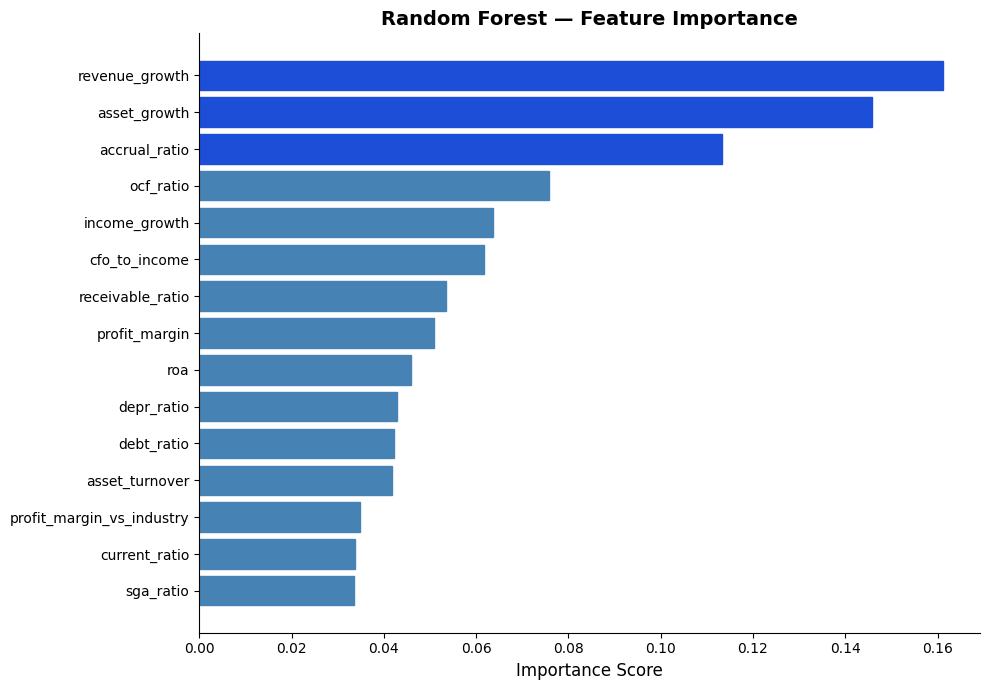

Saved as feature_importance.png


In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
feature_names = [
    'roa', 'profit_margin', 'current_ratio', 'debt_ratio', 'asset_turnover',
    'ocf_ratio', 'sga_ratio', 'depr_ratio',
    'revenue_growth', 'asset_growth', 'income_growth',
    'accrual_ratio', 'cfo_to_income', 'receivable_ratio', 'profit_margin_vs_industry'
]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')

# Color top 3 differently
colors = ['#1d4ed8' if v >= importance_df['Importance'].nlargest(3).min()
          else 'steelblue' for v in importance_df['Importance']]
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as feature_importance.png")